In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Tell pandas to expect gzip compression
# Make sure the file 'model_training_dataset.csv.gz' is in the '/content/' directory in your environment
df = pd.read_csv('/kaggle/input/nasa-train/model_training_dataset.csv')

# This will print the dimensions of your DataFrame
print(f"The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")

The DataFrame has 21238 rows and 9 columns.


In [16]:
df.head()

,lat,lon,time,chlor_a,sst,ssha,day_sin,day_cos,presence
0,8.906417,119.976533,2023-04-14 00:00:00,0.916483,31.390000,0.118,0.976011,-0.217723,1
1,8.906417,119.976533,2023-04-14 00:00:00,0.916483,31.390000,0.118,0.976011,-0.217723,1
2,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1
3,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1
4,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1


In [17]:
print(df.isnull().sum()[df.isnull().sum() > 0])  # Missing value summary

Series([], dtype: int64)


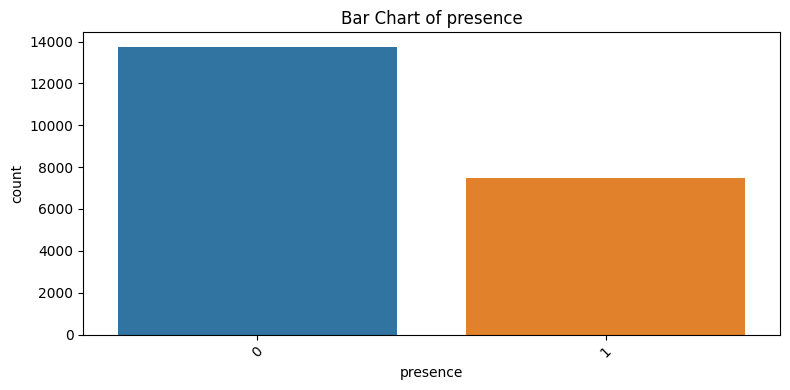

In [18]:
categorical_cols = ['presence']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Feature Engineering

In [19]:
# Libraries
import pandas as pd # Dataframes
import numpy as np
import matplotlib.pyplot as plt # Visualization
import seaborn as sns # Visualization
from sklearn.preprocessing import OneHotEncoder # Encoding with categorical data
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import missingno as msno # Visualizing null values
from sklearn.impute import KNNImputer # Filling in null values for numeric data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

lat         0
lon         0
time        0
chlor_a     0
sst         0
ssha        0
day_sin     0
day_cos     0
presence    0
dtype: int64


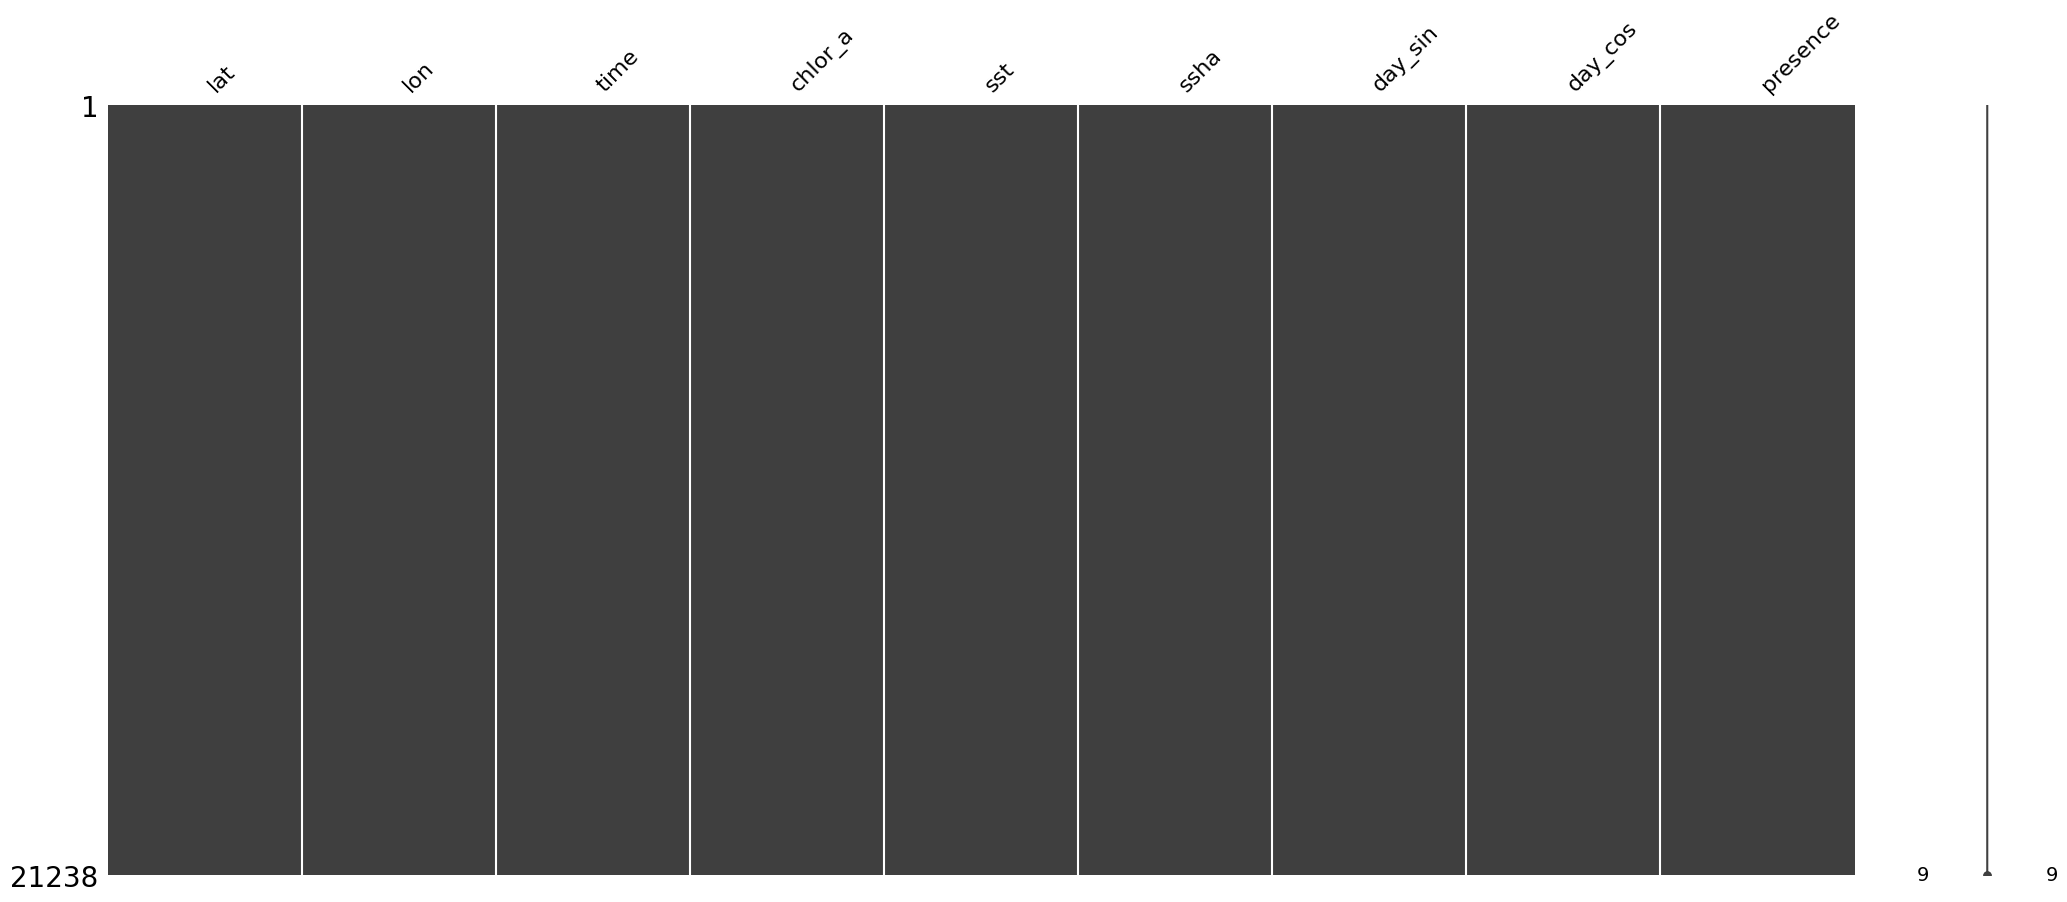

<Figure size 600x300 with 0 Axes>

In [20]:
# Null values
nas = df.isna().sum()
print(nas)

# Visualizing Null values (image)
msno.matrix(df)
plt.figure(figsize = (6,3))
plt.show()

In [21]:
df.head()

,lat,lon,time,chlor_a,sst,ssha,day_sin,day_cos,presence
0,8.906417,119.976533,2023-04-14 00:00:00,0.916483,31.390000,0.118,0.976011,-0.217723,1
1,8.906417,119.976533,2023-04-14 00:00:00,0.916483,31.390000,0.118,0.976011,-0.217723,1
2,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1
3,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1
4,8.848100,119.932083,2023-04-14 00:00:00,1.950458,31.179998,0.118,0.976011,-0.217723,1


# Feature engineering with TIME and SST column

## Biological Significance:
### Hour Features (hour_sin, hour_cos)

1. Diel Vertical Migration: Many marine species (including shark prey) migrate vertically daily
2. Feeding Patterns: Sharks often feed at dawn/dusk when prey is most active
3. Light Penetration: Affects predator-prey interactions and shark hunting behavior
4. Tidal Influences: Coastal sharks follow tidal feeding schedules

### Month Features (month_sin, month_cos)

1. Seasonal Migrations: Sharks follow temperature and prey patterns seasonally
2. Breeding Cycles: Many species have specific breeding seasons
3. Ocean Productivity: Seasonal phytoplankton blooms affect entire food chain
4. Temperature Cycles: Seasonal thermal habitat shifts

### Productivity-Temperature Interaction

1. Metabolic Optimization: Warm water + high productivity = ideal feeding conditions
2. Prey Density: High chlorophyll + optimal temperature = maximum prey availability
3. Energy Balance: Sharks need efficient foraging (high prey in comfortable temperatures)

In [22]:
# Load dataset with datetime parsing
df = pd.read_csv("/kaggle/input/nasa-train/model_training_dataset.csv", parse_dates=["time"])

# Extract hour and month from time column
df["hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month

# Cyclical encoding for hour (0-23)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding for month (1-12)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Optional: drop raw hour/month columns if not needed
df = df.drop(columns=["hour", "month"])

df.head()

,lat,lon,time,chlor_a,sst,ssha,day_sin,day_cos,presence,hour_sin,hour_cos,month_sin,month_cos
0,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5
1,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5
2,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5
3,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5
4,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5


In [23]:
# Productivity-temperature interaction
df['productivity_temp_interaction'] = df['chlor_a'] * df['sst']

In [24]:
df.head()

,lat,lon,time,chlor_a,sst,ssha,day_sin,day_cos,presence,hour_sin,hour_cos,month_sin,month_cos,productivity_temp_interaction
0,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398
1,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398
2,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267
3,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267
4,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267


# Feature Engineering with SSH

## Why These Features Are Powerful:
### 1. upwelling_proxy

- Biology: Upwelling brings nutrient-rich deep water to surface → phytoplankton bloom → attracts prey fish → attracts sharks
- Signal: Captures areas where cold, nutrient-rich water is actively being brought to surface
- Expected Impact: Should be strongly predictive, especially for filter-feeding sharks and areas near continental margins

### 2. eddy_productivity

- Biology: Combines water column dynamics (SSHA) with biological productivity (Chlor_a)
- Signal: Positive values = high productivity in anticyclonic eddies; Negative values = productive cyclonic eddies
- Expected Impact: Continuous variable that captures the intensity of bio-physical coupling

### 3. productive_eddy

- Biology: Specifically targets cyclonic eddies (cold-core, upwelling) with high biological activity
- Signal: Binary flag for prime foraging habitat - cold-core eddies are productivity hotspots
- Expected Impact: Should be highly predictive for predatory sharks following prey aggregations

In [25]:
# SSHA Interaction Features
# 1. Upwelling detection (cold water + negative sea height anomaly)
df['upwelling_proxy'] = (df['ssha'] < -0.05) & (df['sst'] < df['sst'].quantile(0.3))
df['upwelling_proxy'] = df['upwelling_proxy'].astype(int)

# 2. Eddy productivity interaction (combines water dynamics with biological productivity)
df['eddy_productivity'] = df['ssha'] * df['chlor_a']

# 3. Productive eddy zones (cyclonic eddies with high chlorophyll)
df['productive_eddy'] = ((df['ssha'] < -0.1) & (df['chlor_a'] > 1.0)).astype(int)

In [26]:
df.head()

,lat,lon,time,chlor_a,sst,ssha,day_sin,day_cos,presence,hour_sin,hour_cos,month_sin,month_cos,productivity_temp_interaction,upwelling_proxy,eddy_productivity,productive_eddy
0,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0
1,8.906417,119.976533,2023-04-14,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0
2,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0
3,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0
4,8.848100,119.932083,2023-04-14,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0


### Dropping time column

In [27]:
# Extract year
df["year"] = df["time"].dt.year

# Drop raw time column (since features already derived)
df = df.drop(columns=["time"])

In [28]:
df.head()

,lat,lon,chlor_a,sst,ssha,day_sin,day_cos,presence,hour_sin,hour_cos,month_sin,month_cos,productivity_temp_interaction,upwelling_proxy,eddy_productivity,productive_eddy,year
0,8.906417,119.976533,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0,2023
1,8.906417,119.976533,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0,2023
2,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023
3,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023
4,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023


## Dataset After feature engineering

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21238 entries, 0 to 21237
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   lat                            21238 non-null  float64
 1   lon                            21238 non-null  float64
 2   chlor_a                        21238 non-null  float64
 3   sst                            21238 non-null  float64
 4   ssha                           21238 non-null  float64
 5   day_sin                        21238 non-null  float64
 6   day_cos                        21238 non-null  float64
 7   presence                       21238 non-null  int64  
 8   hour_sin                       21238 non-null  float64
 9   hour_cos                       21238 non-null  float64
 10  month_sin                      21238 non-null  float64
 11  month_cos                      21238 non-null  float64
 12  productivity_temp_interaction  21238 non-null 

In [30]:
# 1. Count total columns (features)
total_features = df.shape[1]
print("Total features (including target):", total_features)

# 2. If you want to verify which they are:
print(df.columns.tolist())

Total features (including target): 17
['lat', 'lon', 'chlor_a', 'sst', 'ssha', 'day_sin', 'day_cos', 'presence', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'productivity_temp_interaction', 'upwelling_proxy', 'eddy_productivity', 'productive_eddy', 'year']


In [31]:
import numpy as np

# 1. Numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric features ({}):".format(len(numeric_cols)), numeric_cols)

# 2. Categorical features
#    (anything that isn’t numeric—e.g. object, category, bool)
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Categorical features ({}):".format(len(categorical_cols)), categorical_cols)

Numeric features (17): ['lat', 'lon', 'chlor_a', 'sst', 'ssha', 'day_sin', 'day_cos', 'presence', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'productivity_temp_interaction', 'upwelling_proxy', 'eddy_productivity', 'productive_eddy', 'year']
Categorical features (0): []


In [32]:
# Check your exact year distribution first
print("Year distribution in the dataset:")

print(df['year'].value_counts().sort_index())

print(f"Total samples per year:")
for year in sorted(df['year'].unique()):
    count = len(df[df['year'] == year])
    print(f"{year}: {count} samples")

Year distribution in the dataset:
year
2020    4826
2021    5086
2022    2841
2023    4224
2024    3050
2025    1211
Name: count, dtype: int64
Total samples per year:
2020: 4826 samples
2021: 5086 samples
2022: 2841 samples
2023: 4224 samples
2024: 3050 samples
2025: 1211 samples


# how shark presence (0/1) varies with these new features.

# correlation heatmap of all features vs presence

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


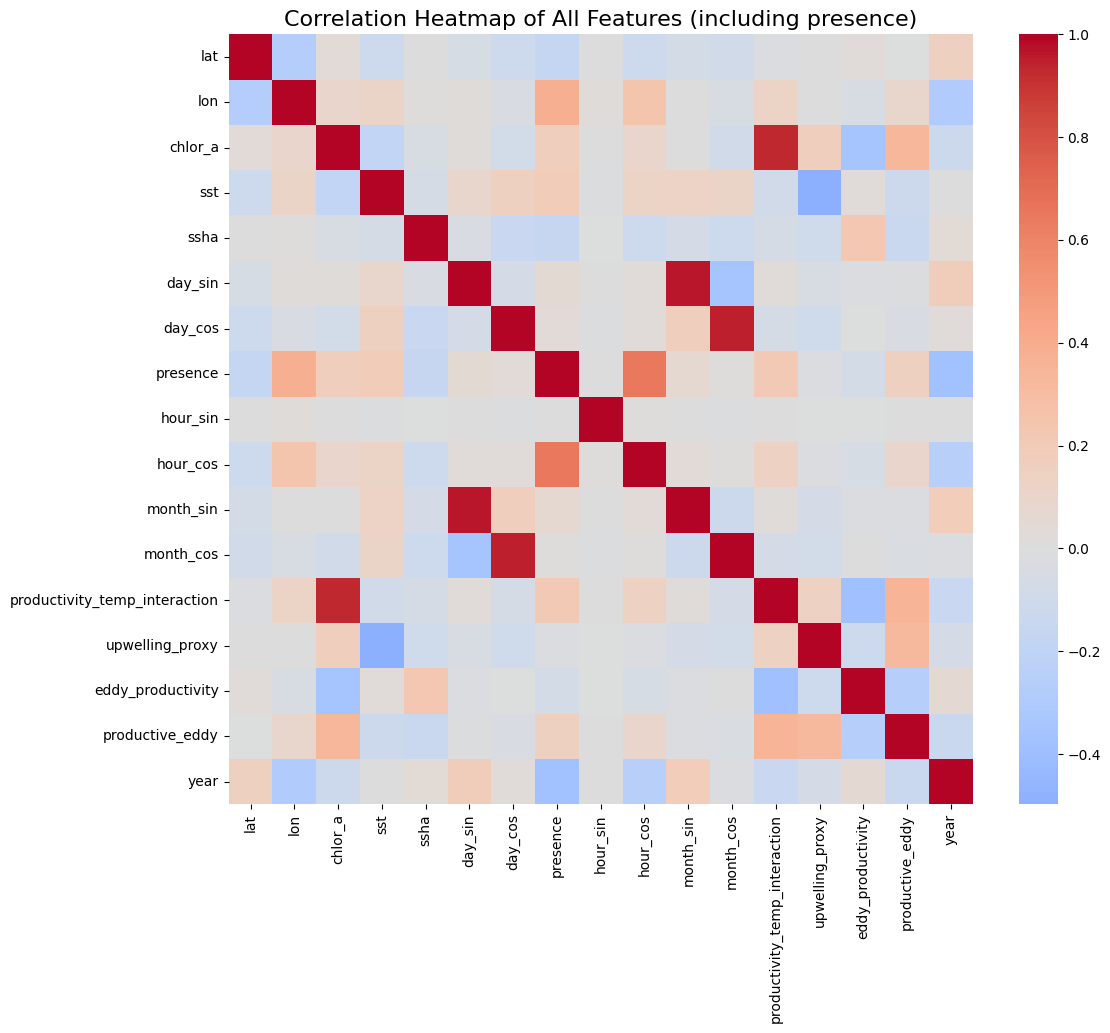

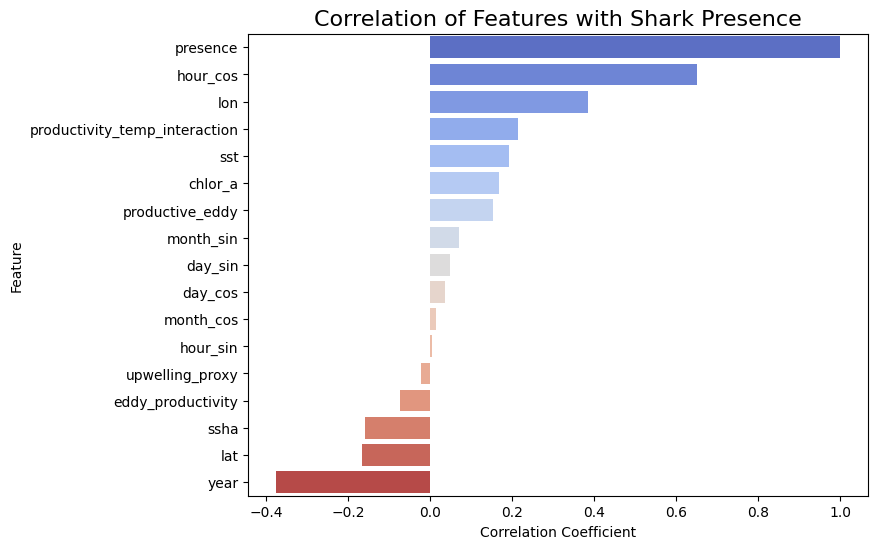

Correlation of each feature with presence:

presence                         1.000000
hour_cos                         0.650837
lon                              0.385796
productivity_temp_interaction    0.213250
sst                              0.192930
chlor_a                          0.167330
productive_eddy                  0.153966
month_sin                        0.069082
day_sin                          0.048025
day_cos                          0.036527
month_cos                        0.013645
hour_sin                         0.005320
upwelling_proxy                 -0.023097
eddy_productivity               -0.075194
ssha                            -0.158263
lat                             -0.167428
year                            -0.375452
Name: presence, dtype: float64


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# 1. Heatmap of all features (with presence included)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, cbar=True)
plt.title("Correlation Heatmap of All Features (including presence)", fontsize=16)
plt.show()

# 2. Correlation of each feature with presence
presence_corr = corr["presence"].sort_values(ascending=False)

# Barplot
plt.figure(figsize=(8,6))
sns.barplot(x=presence_corr.values, y=presence_corr.index, palette="coolwarm")
plt.title("Correlation of Features with Shark Presence", fontsize=16)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

# Print exact correlation values
print("Correlation of each feature with presence:\n")
print(presence_corr)

=== CORRELATION HEATMAP ANALYSIS ===


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


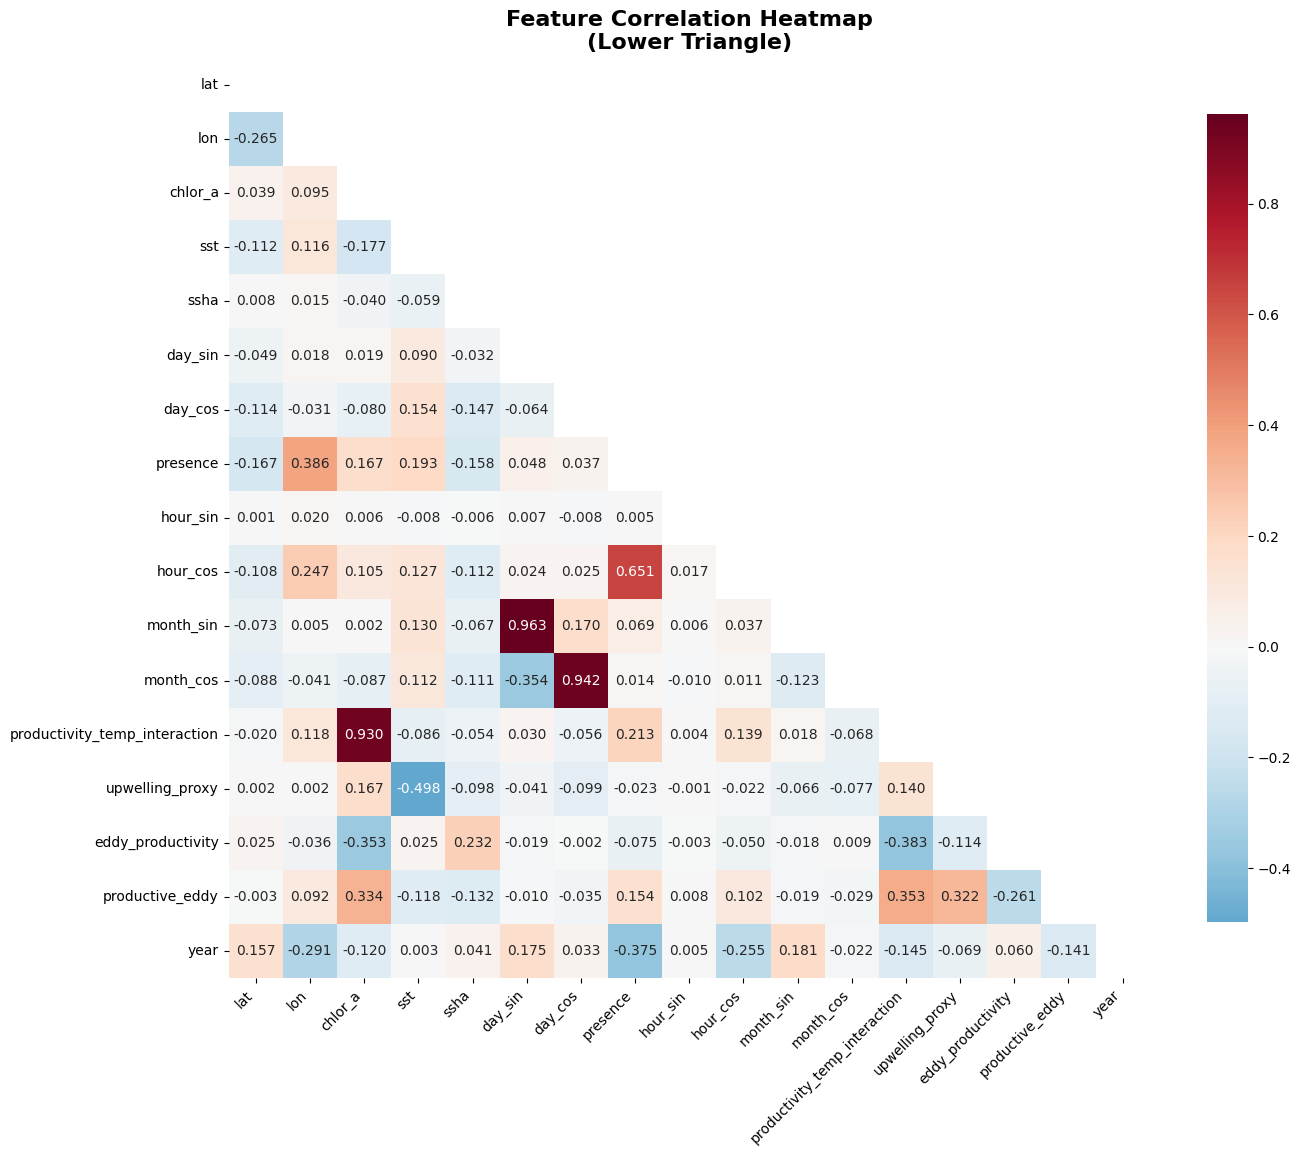


=== INDIVIDUAL FEATURE CORRELATIONS WITH 'PRESENCE' ===

Feature Correlations with 'presence' (sorted by absolute correlation strength):
hour_cos                     | Pearson:  0.6508*** | Spearman:  0.8177***
lon                          | Pearson:  0.3858*** | Spearman:  0.3826***
year                         | Pearson: -0.3755*** | Spearman: -0.3637***
productivity_temp_interaction | Pearson:  0.2133*** | Spearman:  0.5841***
sst                          | Pearson:  0.1929*** | Spearman:  0.1462***
lat                          | Pearson: -0.1674*** | Spearman: -0.1464***
chlor_a                      | Pearson:  0.1673*** | Spearman:  0.4839***
ssha                         | Pearson: -0.1583*** | Spearman: -0.0364***
productive_eddy              | Pearson:  0.1540*** | Spearman:  0.1540***
eddy_productivity            | Pearson: -0.0752*** | Spearman: -0.0886***
month_sin                    | Pearson:  0.0691*** | Spearman:  0.0705***
day_sin                      | Pearson:  0.0480

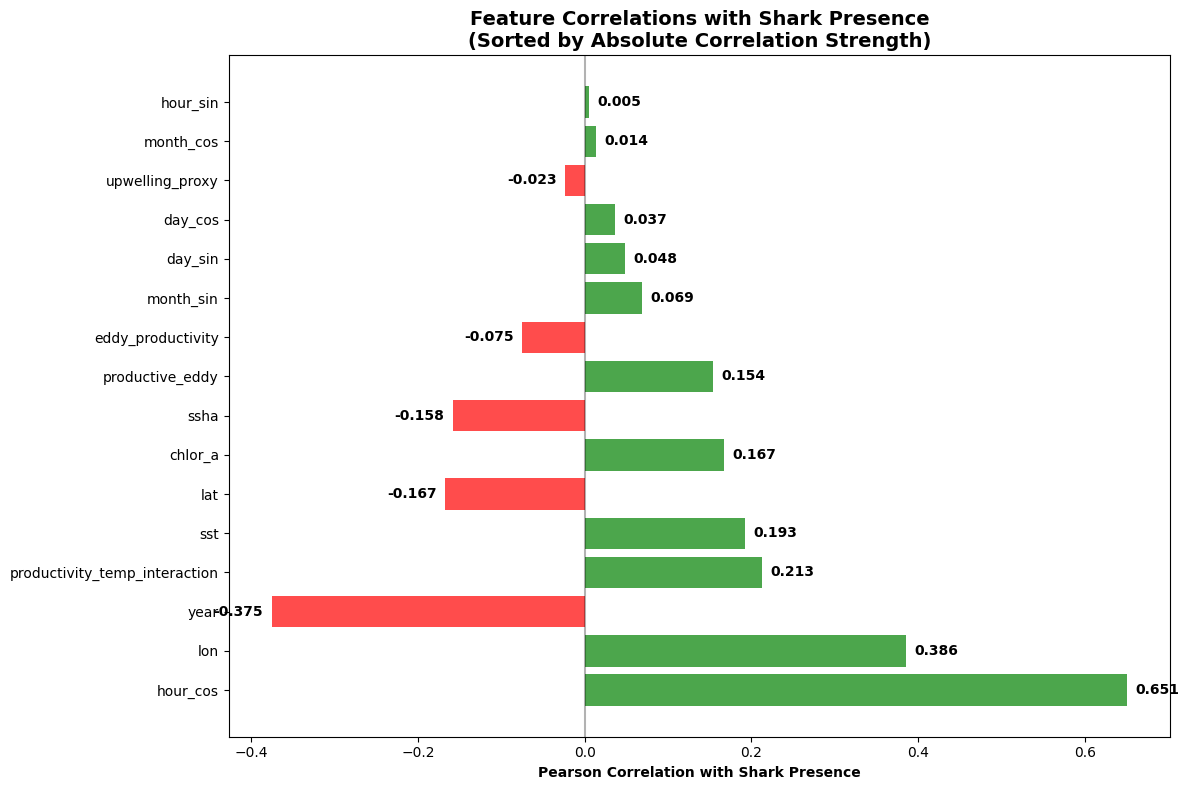


=== TARGET CORRELATIONS SUMMARY ===

All correlations with 'presence' (sorted by absolute value):
--------------------------------------------------
hour_cos                     |  0.6508 | Strong   Positive
lon                          |  0.3858 | Strong   Positive
year                         | -0.3755 | Strong   Negative
productivity_temp_interaction |  0.2133 | Moderate Positive
sst                          |  0.1929 | Moderate Positive
lat                          | -0.1674 | Moderate Negative
chlor_a                      |  0.1673 | Moderate Positive
ssha                         | -0.1583 | Moderate Negative
productive_eddy              |  0.1540 | Moderate Positive
eddy_productivity            | -0.0752 | Weak     Negative
month_sin                    |  0.0691 | Weak     Positive
day_sin                      |  0.0480 | Weak     Positive
day_cos                      |  0.0365 | Weak     Positive
upwelling_proxy              | -0.0231 | Weak     Negative
month_cos              

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Assuming your dataframe is named 'df'
# df = your_dataframe_here

# Set style for better plots
plt.style.use('default')
sns.set_palette("viridis")

# 1. CORRELATION HEATMAP OF ALL FEATURES VS ALL FEATURES
print("=== CORRELATION HEATMAP ANALYSIS ===")

# Calculate correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
heatmap = sns.heatmap(correlation_matrix, 
                     annot=True, 
                     cmap='RdBu_r', 
                     center=0,
                     square=True, 
                     fmt='.3f',
                     cbar_kws={"shrink": .8},
                     mask=mask)

plt.title('Feature Correlation Heatmap\n(Lower Triangle)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. INDIVIDUAL FEATURE CORRELATIONS WITH TARGET (PRESENCE)
print("\n=== INDIVIDUAL FEATURE CORRELATIONS WITH 'PRESENCE' ===")

# Get all features except the target
features = [col for col in df.columns if col != 'presence']

# Calculate correlations with target
correlations_with_target = []

for feature in features:
    # Pearson correlation
    pearson_corr, pearson_p = pearsonr(df[feature], df['presence'])
    
    # Spearman correlation (for non-linear relationships)
    spearman_corr, spearman_p = spearmanr(df[feature], df['presence'])
    
    correlations_with_target.append({
        'Feature': feature,
        'Pearson_Correlation': pearson_corr,
        'Pearson_p_value': pearson_p,
        'Spearman_Correlation': spearman_corr,
        'Spearman_p_value': spearman_p,
        'Abs_Pearson': abs(pearson_corr)
    })

# Convert to DataFrame for better visualization
corr_df = pd.DataFrame(correlations_with_target)

# Sort by absolute correlation strength
corr_df_sorted = corr_df.sort_values('Abs_Pearson', ascending=False)

# Display results
print("\nFeature Correlations with 'presence' (sorted by absolute correlation strength):")
print("=" * 80)
for idx, row in corr_df_sorted.iterrows():
    significance_p = "***" if row['Pearson_p_value'] < 0.001 else "**" if row['Pearson_p_value'] < 0.01 else "*" if row['Pearson_p_value'] < 0.05 else ""
    significance_s = "***" if row['Spearman_p_value'] < 0.001 else "**" if row['Spearman_p_value'] < 0.01 else "*" if row['Spearman_p_value'] < 0.05 else ""
    
    print(f"{row['Feature']:28} | Pearson: {row['Pearson_Correlation']:7.4f}{significance_p:3} | Spearman: {row['Spearman_Correlation']:7.4f}{significance_s:3}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05")

# 3. VISUALIZATION: BAR PLOT OF CORRELATIONS WITH TARGET
plt.figure(figsize=(12, 8))

# Create bar plot
y_pos = np.arange(len(corr_df_sorted))
colors = ['red' if x < 0 else 'green' for x in corr_df_sorted['Pearson_Correlation']]

bars = plt.barh(y_pos, corr_df_sorted['Pearson_Correlation'], color=colors, alpha=0.7)

# Customize plot
plt.yticks(y_pos, corr_df_sorted['Feature'])
plt.xlabel('Pearson Correlation with Shark Presence', fontweight='bold')
plt.title('Feature Correlations with Shark Presence\n(Sorted by Absolute Correlation Strength)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Add correlation values on bars
for i, (bar, corr) in enumerate(zip(bars, corr_df_sorted['Pearson_Correlation'])):
    plt.text(corr + (0.01 if corr > 0 else -0.01), i, f'{corr:.3f}', 
             ha='left' if corr > 0 else 'right', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. CORRELATION SPECIFICALLY WITH TARGET VARIABLE
print("\n=== TARGET CORRELATIONS SUMMARY ===")
target_correlations = df.corr()['presence'].sort_values(key=abs, ascending=False)

print("\nAll correlations with 'presence' (sorted by absolute value):")
print("-" * 50)
for feature, corr in target_correlations.items():
    if feature != 'presence':
        strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.1 else "Weak"
        direction = "Positive" if corr > 0 else "Negative"
        print(f"{feature:28} | {corr:7.4f} | {strength:8} {direction}")

# 5. IDENTIFY HIGHLY CORRELATED FEATURE PAIRS (for potential multicollinearity)
print("\n=== HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7) ===")
high_corr_pairs = []

for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_val = correlation_matrix.loc[features[i], features[j]]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((features[i], features[j], corr_val))

if high_corr_pairs:
    print("Features with high correlation (potential multicollinearity):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1} <-> {feat2}: {corr:.4f}")
else:
    print("No highly correlated feature pairs found (|r| > 0.7)")

# 6. BASIC STATISTICS
print(f"\n=== DATASET SUMMARY ===")
print(f"Total samples: {len(df):,}")
print(f"Total features: {len(features)}")
print(f"Shark presence rate: {df['presence'].mean():.1%} ({df['presence'].sum():,} positive cases)")
print(f"Missing values: {df.isnull().sum().sum()} (should be 0 based on your info)")

# 7. TOP POSITIVE AND NEGATIVE CORRELATIONS WITH TARGET
print(f"\n=== TOP CORRELATIONS WITH SHARK PRESENCE ===")
target_corrs = corr_df_sorted[corr_df_sorted['Feature'] != 'presence']

print("\nTop 5 POSITIVE correlations:")
positive_corrs = target_corrs[target_corrs['Pearson_Correlation'] > 0].head(5)
for _, row in positive_corrs.iterrows():
    print(f"  {row['Feature']:25} | +{row['Pearson_Correlation']:.4f}")

print("\nTop 5 NEGATIVE correlations:")
negative_corrs = target_corrs[target_corrs['Pearson_Correlation'] < 0].head(5)
for _, row in negative_corrs.iterrows():
    print(f"  {row['Feature']:25} | {row['Pearson_Correlation']:.4f}")

In [35]:
df.head()

,lat,lon,chlor_a,sst,ssha,day_sin,day_cos,presence,hour_sin,hour_cos,month_sin,month_cos,productivity_temp_interaction,upwelling_proxy,eddy_productivity,productive_eddy,year
0,8.906417,119.976533,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0,2023
1,8.906417,119.976533,0.916483,31.390000,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,28.768398,0,0.108145,0,2023
2,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023
3,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023
4,8.848100,119.932083,1.950458,31.179998,0.118,0.976011,-0.217723,1,0.0,1.0,0.866025,-0.5,60.815267,0,0.230154,0,2023


# Not scaling any features as i will use tree based models

# Will split the dataset based on year

# performing feature selection

=== Mutual Information Scores with 'presence' ===
                          Feature  Mutual_Information
1                             lon            0.582264
0                             lat            0.569585
8                        hour_cos            0.558901
7                        hour_sin            0.499390
11  productivity_temp_interaction            0.497091
2                         chlor_a            0.476520
3                             sst            0.366240
13              eddy_productivity            0.361295
4                            ssha            0.235539
5                         day_sin            0.185819
6                         day_cos            0.121342
15                           year            0.108186
9                       month_sin            0.026598
10                      month_cos            0.019096
14                productive_eddy            0.008726
12                upwelling_proxy            0.000000


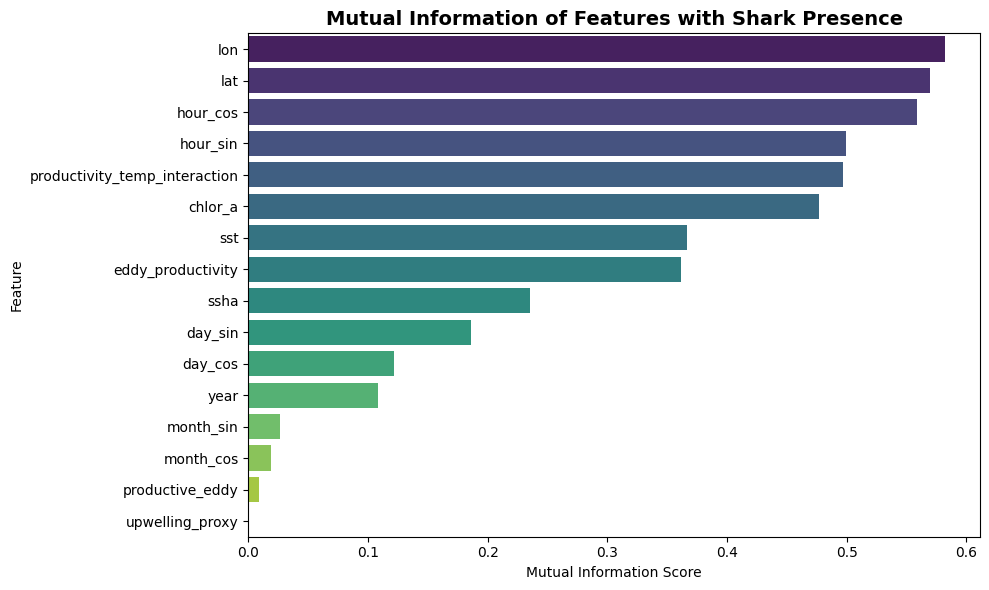

In [36]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Separate features and target
X = df.drop(columns=['presence'])
y = df['presence']

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

# Put into DataFrame
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_scores
}).sort_values('Mutual_Information', ascending=False)

print("=== Mutual Information Scores with 'presence' ===")
print(mi_df)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Mutual_Information', y='Feature', data=mi_df, palette="viridis")
plt.title("Mutual Information of Features with Shark Presence", fontsize=14, fontweight='bold')
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Why Mutual Information?

Unlike correlation, MI can detect nonlinear relationships (e.g., sharks responding strongly to a threshold in SST, not linearly).

Tree-based models benefit more from MI-selected features.

In [37]:
df.drop(columns=['productive_eddy'], inplace=True) 

In [39]:
df.drop(columns=['upwelling_proxy'], inplace=True) 

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21238 entries, 0 to 21237
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   lat                            21238 non-null  float64
 1   lon                            21238 non-null  float64
 2   chlor_a                        21238 non-null  float64
 3   sst                            21238 non-null  float64
 4   ssha                           21238 non-null  float64
 5   day_sin                        21238 non-null  float64
 6   day_cos                        21238 non-null  float64
 7   presence                       21238 non-null  int64  
 8   hour_sin                       21238 non-null  float64
 9   hour_cos                       21238 non-null  float64
 10  month_sin                      21238 non-null  float64
 11  month_cos                      21238 non-null  float64
 12  productivity_temp_interaction  21238 non-null 

In [41]:
# Check your exact year distribution first
print("Year distribution in your dataset:")
print(df['year'].value_counts().sort_index())
print(f"Total samples per year:")
for year in sorted(df['year'].unique()):
    count = len(df[df['year'] == year])
    print(f"{year}: {count} samples")

Year distribution in your dataset:
year
2020    4826
2021    5086
2022    2841
2023    4224
2024    3050
2025    1211
Name: count, dtype: int64
Total samples per year:
2020: 4826 samples
2021: 5086 samples
2022: 2841 samples
2023: 4224 samples
2024: 3050 samples
2025: 1211 samples


# Data split

In [42]:
# Conservative approach (Recommended for production)
train_years = [2020, 2021, 2022]  # 3 years for training (50%)
val_years = [2023]                 # 1 year for validation (16.7%)
test_years = [2024, 2025]         # 2 years for testing (33.3%)

# Apply the split
def create_temporal_split(df, train_years, val_years, test_years):
    train_df = df[df['year'].isin(train_years)].copy()
    val_df = df[df['year'].isin(val_years)].copy()
    test_df = df[df['year'].isin(test_years)].copy()
    
    return train_df, val_df, test_df

train_df, val_df, test_df = create_temporal_split(df, train_years, val_years, test_years)

print("Dataset Split Summary:")
print(f"Train (2020-2022): {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val (2023): {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test (2024-2025): {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

Dataset Split Summary:
Train (2020-2022): 12753 samples (60.0%)
Val (2023): 4224 samples (19.9%)
Test (2024-2025): 4261 samples (20.1%)


In [43]:
# =============================
# 2. Feature/Target Preparation
# =============================
drop_features = ["productive_eddy", "upwelling_proxy"]  # Dropped after MI analysis
target = "presence"

features = [col for col in df.columns if col not in drop_features + [target]]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val     = val_df[features], val_df[target]
X_test, y_test   = test_df[features], test_df[target]

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [48]:
# =============================
# 3. Define Models
# =============================
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# train


================= RandomForest =================

— Validation —
Classification Report:
              precision    recall  f1-score   support

           0     0.8723    0.9977    0.9308      3019
           1     0.9909    0.6340    0.7733      1205

    accuracy                         0.8939      4224
   macro avg     0.9316    0.8159    0.8520      4224
weighted avg     0.9061    0.8939    0.8858      4224

ROC-AUC: 0.9933


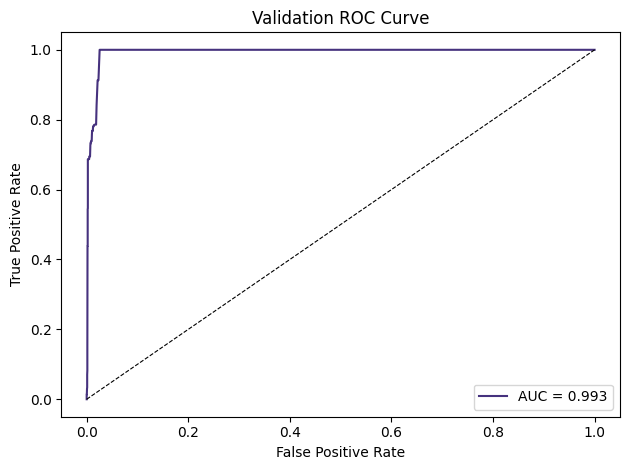

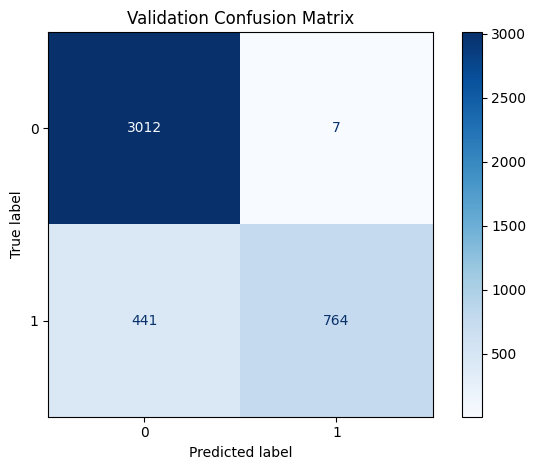


— Test —
Classification Report:
              precision    recall  f1-score   support

           0     0.9926    0.9971    0.9949      4185
           1     0.7895    0.5921    0.6767        76

    accuracy                         0.9899      4261
   macro avg     0.8910    0.7946    0.8358      4261
weighted avg     0.9890    0.9899    0.9892      4261

ROC-AUC: 0.9923


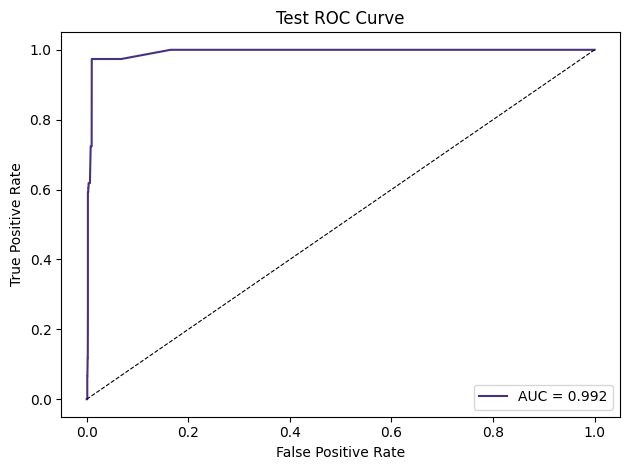

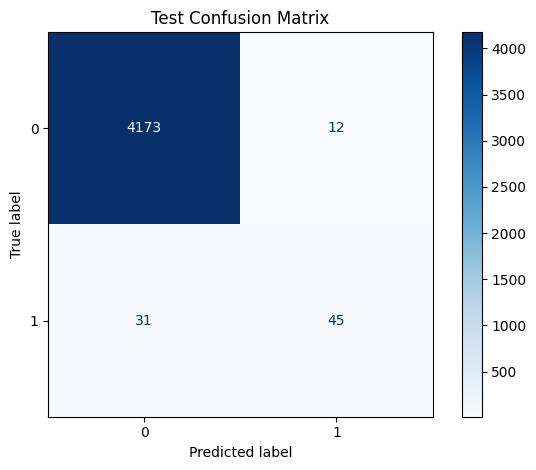


================= XGBoost =================

— Validation —
Classification Report:
              precision    recall  f1-score   support

           0     0.8953    0.9970    0.9434      3019
           1     0.9896    0.7079    0.8254      1205

    accuracy                         0.9145      4224
   macro avg     0.9424    0.8525    0.8844      4224
weighted avg     0.9222    0.9145    0.9097      4224

ROC-AUC: 0.9945


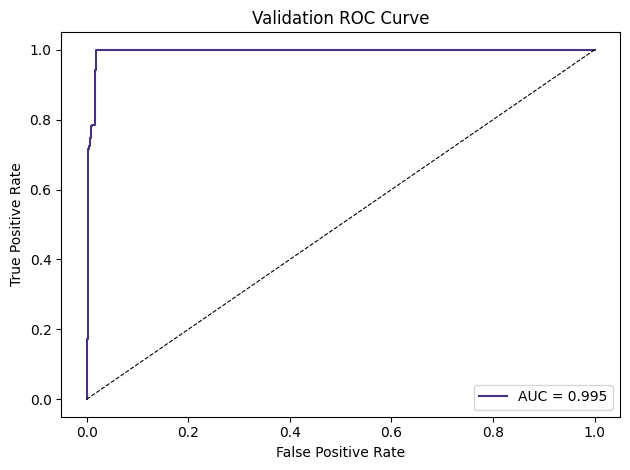

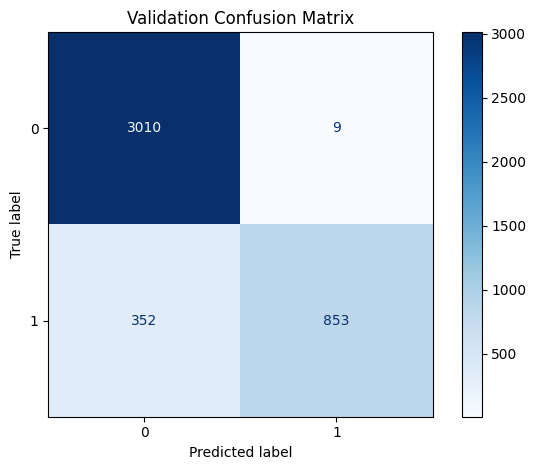


— Test —
Classification Report:
              precision    recall  f1-score   support

           0     0.9931    0.9969    0.9950      4185
           1     0.7833    0.6184    0.6912        76

    accuracy                         0.9901      4261
   macro avg     0.8882    0.8077    0.8431      4261
weighted avg     0.9894    0.9901    0.9896      4261

ROC-AUC: 0.9961


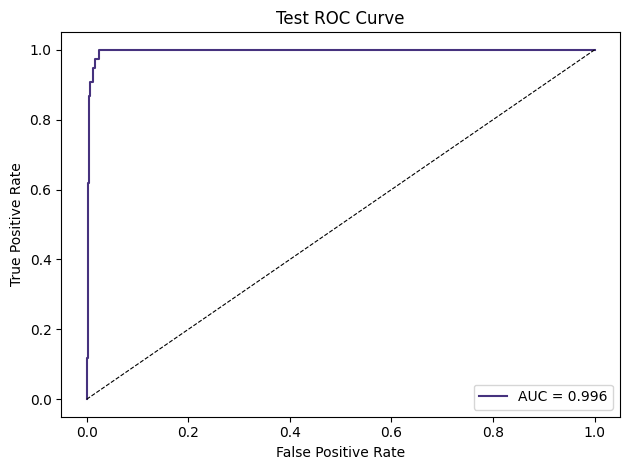

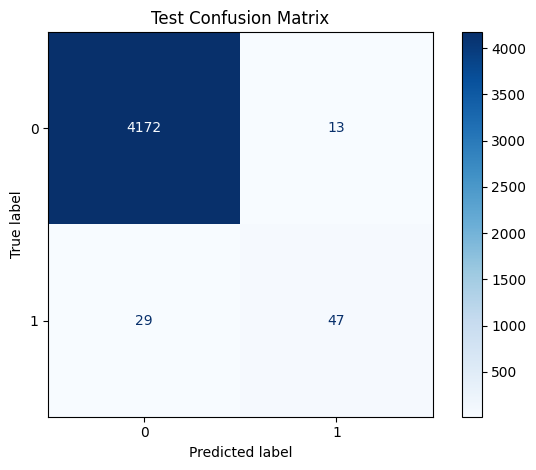


================= LightGBM =================
[LightGBM] [Info] Number of positive: 6205, number of negative: 6548
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2333
[LightGBM] [Info] Number of data points in the train set: 12753, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.486552 -> initscore=-0.053804
[LightGBM] [Info] Start training from score -0.053804

— Validation —
Classification Report:
              precision    recall  f1-score   support

           0     0.8030    0.9967    0.8894      3019
           1     0.9790    0.3876    0.5553      1205

    accuracy                         0.8229      4224
   macro avg     0.8910    0.6921    0.7224      4224
weighted avg     0.8532    0.8229    0.7941      4224

ROC-AUC: 0.9941


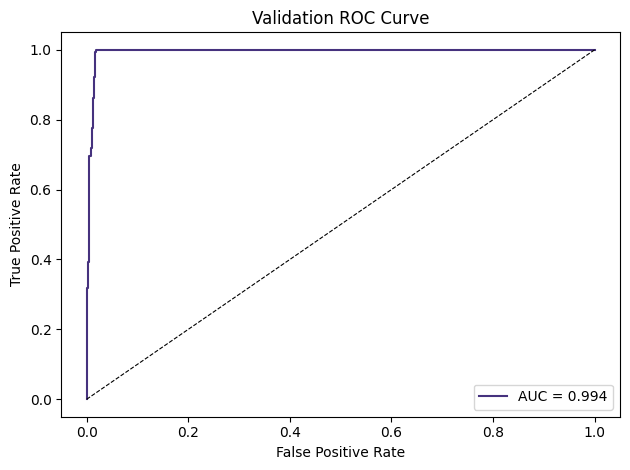

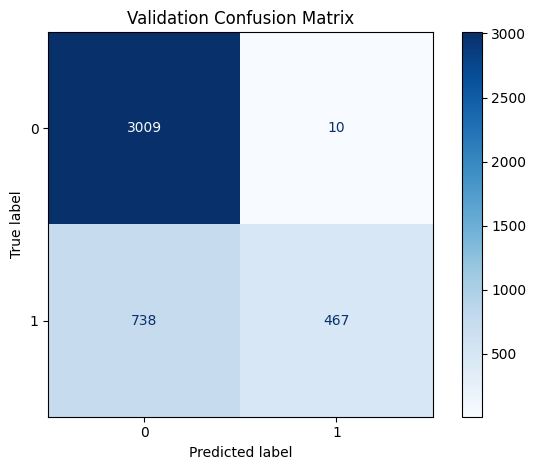


— Test —
Classification Report:
              precision    recall  f1-score   support

           0     0.9926    0.9974    0.9950      4185
           1     0.8036    0.5921    0.6818        76

    accuracy                         0.9901      4261
   macro avg     0.8981    0.7947    0.8384      4261
weighted avg     0.9893    0.9901    0.9894      4261

ROC-AUC: 0.9962


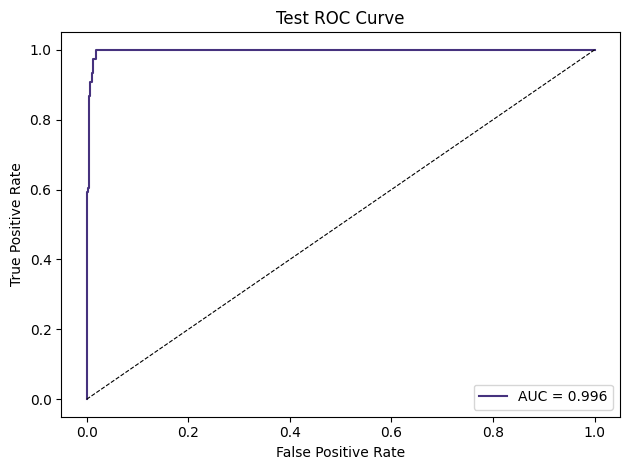

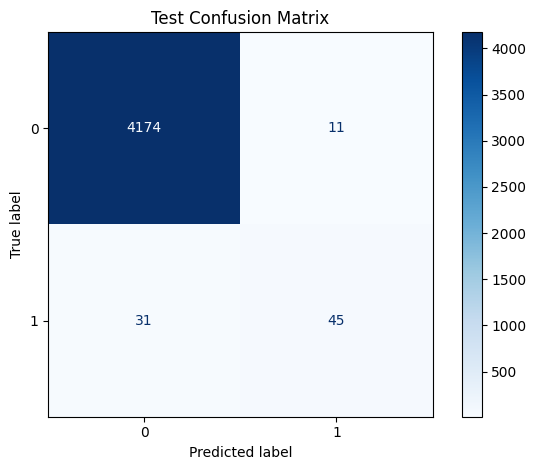

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_and_plot(model, X, y, split_name="Test"):
    """
    Prints a classification report and ROC-AUC, then plots ROC curve and confusion matrix.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # Text summary
    print(f"\n— {split_name} —")
    print("Classification Report:")
    print(classification_report(y, y_pred, digits=4))
    roc_auc = roc_auc_score(y, y_prob)
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{split_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(f'{split_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# 2) Train on Train, evaluate on Validation and Test for each model
for name, model in models.items():
    print(f"\n================= {name} =================")
    model.fit(X_train, y_train)

    # Validation
    evaluate_and_plot(model, X_val, y_val, split_name="Validation")

    # Test
    evaluate_and_plot(model, X_test, y_test, split_name="Test")

In [61]:
# Get target distributions
train_dist = y_train.value_counts()
val_dist = y_val.value_counts()
test_dist = y_test.value_counts()

# Print distributions
print("=== Target Class Distribution ===")
print(f"\nTrain Set (2020-2022): {train_dist}")
print(f"Validation Set (2023): {val_dist}")
print(f"Test Set (2024-2025): {test_dist}")

# Optional: Calculate percentages
print("\n=== Target Class Percentages ===")
print(f"Train Set: {train_dist / len(y_train) * 100}%")
print(f"Validation Set: {val_dist / len(y_val) * 100}%")
print(f"Test Set: {test_dist / len(y_test) * 100}%")

=== Target Class Distribution ===

Train Set (2020-2022): presence
0    6548
1    6205
Name: count, dtype: int64
Validation Set (2023): presence
0    3019
1    1205
Name: count, dtype: int64
Test Set (2024-2025): presence
0    4185
1      76
Name: count, dtype: int64

=== Target Class Percentages ===
Train Set: presence
0    51.344782
1    48.655218
Name: count, dtype: float64%
Validation Set: presence
0    71.472538
1    28.527462
Name: count, dtype: float64%
Test Set: presence
0    98.216381
1     1.783619
Name: count, dtype: float64%


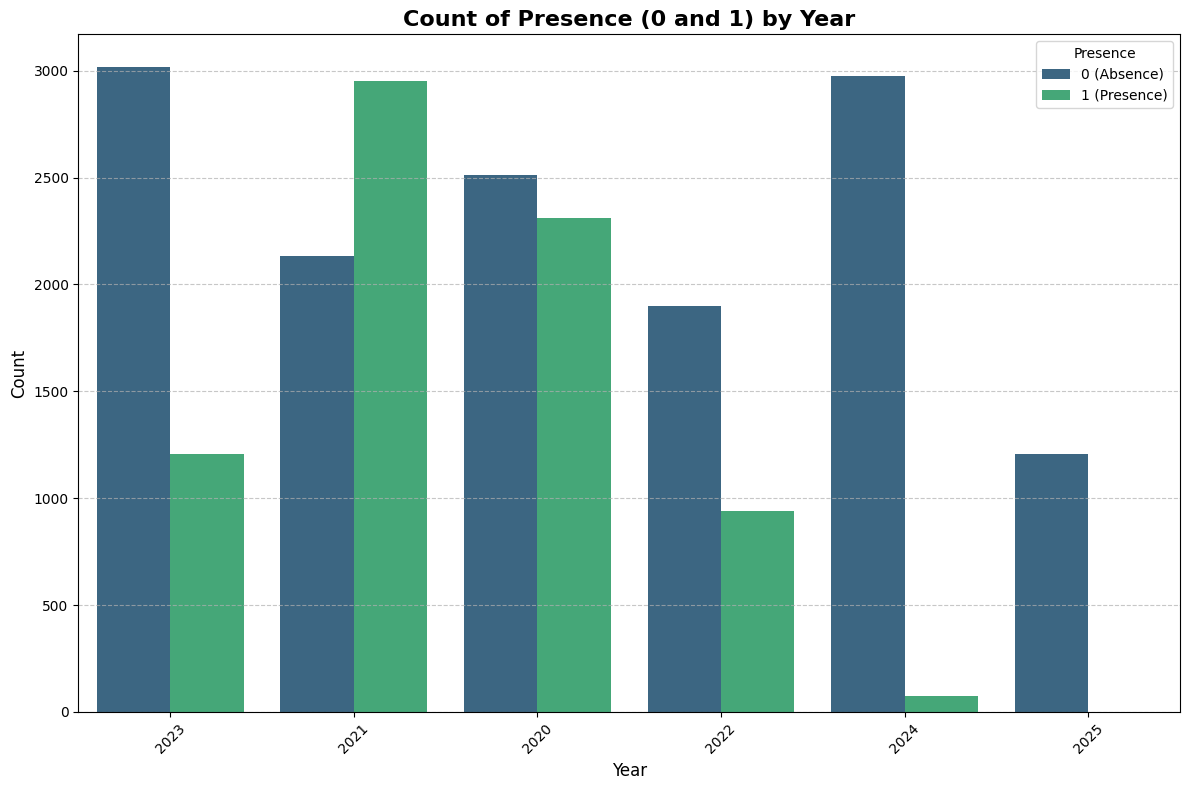

Visualization complete. The plot has been generated.


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_checker = df
# Step 1: Ensure the columns have the correct data types
# This step is good practice to prevent errors
df_checker['year'] = df_checker['year'].astype(str)
df_checker['presence'] = df_checker['presence'].astype(int)

# Step 2: Create the grouped bar chart
plt.figure(figsize=(12, 8))
sns.countplot(x='year', hue='presence', data=df_checker, palette='viridis')

# Step 3: Add titles and labels for clarity
plt.title('Count of Presence (0 and 1) by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add a legend to distinguish between 0 and 1
plt.legend(title='Presence', labels=['0 (Absence)', '1 (Presence)'])

# Step 5: Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualization complete. The plot has been generated.")